# Notebook 05 — Sensitivity Analysis

**Purpose.** Notebooks 03–04 estimated the BRS − H3 lifetime
value difference and the DoD fiscal cost. This notebook
stress-tests those results: how much do the conclusions
depend on the model's key assumptions?

Three analyses:

1. **One-at-a-time (OAT) sensitivity** — vary each input
   alone and rank the drivers (tornado chart).
2. **Scenario analysis** — bundle inputs into named market
   regimes and track the BRS/H3 crossover across careers.
3. **Separation-timing sensitivity** — reweight the fiscal
   model's separation distribution and test the per-entrant
   DoD-savings conclusion.

**Framing.** Every result is the **BRS − H3 difference** in
net present value at separation, constant 2026 dollars.
Positive favors BRS; negative favors High-Three. The 5%
nominal discount rate is the baseline unless noted.

## Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, "../src")
from monte_carlo import (
    fit_fund_stats,
    fit_cola_stats,
    run_scenario,
)

In [2]:
BASE = "../data/processed"
pay_df = pd.read_csv(f"{BASE}/pay_profiles.csv")
life_df = pd.read_csv(f"{BASE}/life_expectancy.csv")
tsp_df = pd.read_csv(f"{BASE}/tsp_returns.csv")
cpi_df = pd.read_csv(f"{BASE}/cpi_inflation.csv")

ENTRY_AGES = {"Officer": 22, "Enlisted": 18,
              "PriorEnlistedOfficer": 18}

# Display order and labels: Enlisted -> PEO -> Officer.
PROFILE_TITLES = {
    "Enlisted": "Enlisted",
    "PriorEnlistedOfficer": "Prior-Enlisted Officer",
    "Officer": "Officer",
}
# Modeled separation grid: 2-yr spacing to the statutory
# maximum (officer / PEO 40, enlisted 30).
VALID_SCENARIOS = {
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": list(range(4, 41, 2)),
    "Officer": list(range(4, 41, 2)),
}

In [3]:
# Fit the two empirical input distributions once.
fund_stats = fit_fund_stats(tsp_df)
# COLA draw = lifetime-average inflation, fit on rolling
# 30-yr average CPI (same basis as nb03b / nb04).
cola_stats = fit_cola_stats(cpi_df, window=30)

DISCOUNT_RATE = 0.05
N_ITER = 20_000
RNG_SEED = 42


def shift_fund_means(fs, delta):
    """Copy fund_stats with every fund mean shifted by delta."""
    return {f: {"mean": s["mean"] + delta, "std": s["std"]}
            for f, s in fs.items()}


print(f"COLA baseline : mean {cola_stats['mean']:.2%}, "
      f"std {cola_stats['std']:.2%}")
print(f"MC settings   : N={N_ITER:,}, seed={RNG_SEED}, "
      f"discount={DISCOUNT_RATE:.0%}")

COLA baseline : mean 3.39%, std 1.27%
MC settings   : N=20,000, seed=42, discount=5%


## 1. One-at-a-Time (OAT) Sensitivity

**Anchor: Officer / 20 YOS** — the pension-cliff retirement
point, where both the pension-formula penalty and the full
TSP match are at stake, so sensitivities are largest here.
Each parameter moves to a low/high bound with all others at
their baseline (COLA 3.4%, glide-path return means, 5%
member contribution, SSA 2022 male tables, 5% discount). The
tornado ranks parameters by the resulting swing in the P50
BRS − H3 difference.

| Parameter | Low | High | Bound represents |
|---|---|---|---|
| COLA mean | 1.5% | 5.0% | historical range of 30-yr avg inflation |
| TSP return | −1 SE | +1 SE | uncertainty in the historical mean (n=24) |
| Member contrib | 0% | 10% | participation behavior |
| Life expectancy | −10 yr | +10 yr | population-mean uncertainty |
| Discount rate | 3% | 7% | NPV-convention stress |

> **COLA note.** The empirical baseline (≈3.4%) differs from
> nb03a's deterministic 2.75% (DoD actuarial assumption) —
> the higher mean is why the baseline difference here is more
> negative. Empirical vs. actuarial, intentional, not a
> discrepancy.

In [4]:
ANCHOR = ("Officer", 20)


def run_anchor(fs=fund_stats, cs=cola_stats,
               dr=DISCOUNT_RATE, dao=0.0, mbr=0.05):
    """Run the anchor scenario, overriding one OAT input."""
    prof, yos = ANCHOR
    return run_scenario(
        prof, yos, pay_df, life_df, fs, cs, ENTRY_AGES,
        n_iter=N_ITER, discount_rate=dr, seed=RNG_SEED,
        death_age_offset=dao, member_rate=mbr,
    )


# Per-fund ±1 SE of the mean (SE = std / sqrt(n), n=24).
se = {f: tsp_df[f].dropna().std(ddof=1)
      / np.sqrt(tsp_df[f].dropna().size) / 100
      for f in fund_stats}
fs_low = {f: {"mean": fund_stats[f]["mean"] - se[f],
              "std": fund_stats[f]["std"]} for f in fund_stats}
fs_high = {f: {"mean": fund_stats[f]["mean"] + se[f],
               "std": fund_stats[f]["std"]} for f in fund_stats}

# Each OAT parameter: (low kwargs, high kwargs, (low, high) lbls).
OAT = {
    "COLA Rate": (
        dict(cs={"mean": 0.015, "std": cola_stats["std"]}),
        dict(cs={"mean": 0.050, "std": cola_stats["std"]}),
        ("1.5%", "5.0%"),
    ),
    "TSP Return": (
        dict(fs=fs_low), dict(fs=fs_high), ("−1 SE", "+1 SE"),
    ),
    "Member Contrib": (
        dict(mbr=0.0), dict(mbr=0.10), ("0%", "10%"),
    ),
    "Life Expect.": (
        dict(dao=-10.0), dict(dao=10.0), ("−10 yr", "+10 yr"),
    ),
    "Discount Rate": (
        dict(dr=0.03), dict(dr=0.07), ("3%", "7%"),
    ),
}

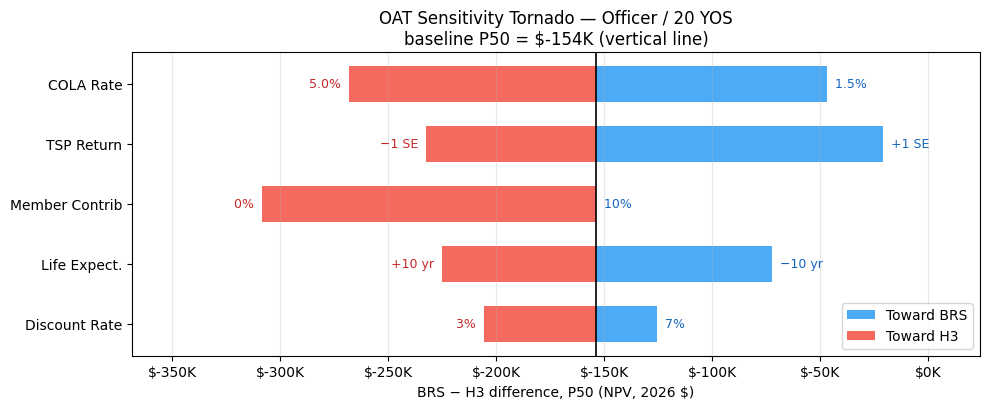

In [5]:
baseline_p50 = float(
    np.percentile(run_anchor()["brs_adv"], 50))

results = []
for name, (lo_kw, hi_kw, _) in OAT.items():
    lo = float(np.percentile(run_anchor(**lo_kw)["brs_adv"], 50))
    hi = float(np.percentile(run_anchor(**hi_kw)["brs_adv"], 50))
    results.append((name, lo, hi))
oat_p50 = {name: (lo, hi) for name, lo, hi in results}

BLUE, RED = "#2196F3", "#F44336"
fig, ax = plt.subplots(figsize=(10, 4.2))
for i, (name, lo, hi) in enumerate(
        sorted(results, key=lambda r: abs(r[2] - r[1]))):
    lo_lbl, hi_lbl = OAT[name][2]
    hi_x, lo_x = max(lo, hi), min(lo, hi)
    blue_lbl = hi_lbl if hi >= lo else lo_lbl
    red_lbl = lo_lbl if hi >= lo else hi_lbl
    ax.barh(i, hi_x - baseline_p50, left=baseline_p50,
            color=BLUE, alpha=0.8, height=0.6,
            label="Toward BRS" if i == 0 else "")
    ax.barh(i, lo_x - baseline_p50, left=baseline_p50,
            color=RED, alpha=0.8, height=0.6,
            label="Toward H3" if i == 0 else "")
    ax.text(hi_x, i, f"  {blue_lbl}", va="center", ha="left",
            fontsize=9, color="#1565C0")
    ax.text(lo_x, i, f"{red_lbl}  ", va="center", ha="right",
            fontsize=9, color="#C62828")
    ax.set_yticks(list(range(len(results))))

ax.axvline(baseline_p50, color="black", lw=1.2, zorder=5)
ax.set_yticklabels([r[0] for r in sorted(
    results, key=lambda r: abs(r[2] - r[1]))])
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
lo_all = min(v for _, a, b in results for v in (a, b))
hi_all = max(v for _, a, b in results for v in (a, b))
ax.set_xlim(lo_all - 60_000, hi_all + 45_000)
ax.set_xlabel("BRS − H3 difference, P50 (NPV, 2026 $)")
ax.set_title(
    "OAT Sensitivity Tornado — Officer / 20 YOS\n"
    f"baseline P50 = ${baseline_p50/1e3:.0f}K (vertical line)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the tornado

Baseline P50 = **−\$153.9K** — at the cliff, High-Three leads.

- **COLA (≈\$222K swing) and TSP return (≈\$211K) dominate.**
  One COLA draw drives pay growth, the pension COLA, and the
  deflator together, and H3's larger 50% multiplier gains
  more from inflation: low COLA narrows the gap to −\$47K,
  high widens it to −\$268K. For returns, +1 SE narrows it to
  −\$21K but never flips the sign.
- **Member contribution (≈\$155K, one-sided).** At 0% the gap
  widens to −\$309K (BRS keeps only its 1% auto contribution);
  at 10% it equals baseline, since the match is fully captured
  at 5%.
- **Life expectancy (≈\$153K).** Longer life favors H3 — more
  pension years: −\$72K at −10 yr, −\$225K at +10 yr.
- **Discount rate (≈\$80K), smallest.** Cheaper discounting of
  the longer-dated pension favors H3 (−\$205K at 3%).

**Takeaway.** Under every single-parameter stress the sign
stays negative; only a favorable TSP return brings BRS within
~\$21K at 20 YOS.

### Female life tables (targeted check)

The baseline uses SSA 2022 **male** tables (~83% of the
force). Women live ~4 yr longer at these ages — more
inflation-protected pension years, favoring H3. Because
`run_scenario` uses the expected death age at the separation
age, passing the male-to-female gap as `death_age_offset`
reproduces the female table at the anchor.

In [6]:
sep_age = ENTRY_AGES["Officer"] + 20
row = life_df.loc[life_df["Age"] == sep_age].iloc[0]
gap = float(row["FemaleTotalAge"] - row["MaleTotalAge"])
female_p50 = float(
    np.percentile(run_anchor(dao=gap)["brs_adv"], 50))
le_lo, le_hi = oat_p50["Life Expect."]

print(f"Sep age {sep_age}: +{gap:.1f} yr male -> female")
print(f"  male   P50 : ${baseline_p50:,.0f}")
print(f"  female P50 : ${female_p50:,.0f}"
      f"  (shift ${female_p50 - baseline_p50:,.0f})")
print(f"  context    : ±10-yr OAT life range "
      f"${abs(le_hi - le_lo):,.0f}")

Sep age 42: +4.1 yr male -> female
  male   P50 : $-153,948
  female P50 : $-184,653  (shift $-30,706)
  context    : ±10-yr OAT life range $152,811


**Result.** Female tables (+4.1 yr) deepen the median
from −\$154K to −\$185K — a −\$31K (~20%) shift toward H3,
well inside the ±10-yr life-expectancy band above. A
population-weighted blend (~17.5% female) would move the
baseline under \$6K, so gender is a targeted check, not a
full model dimension.

## 2. Scenario Analysis

Single-parameter stresses understate joint moves. Four named
regimes bundle returns, COLA, discount, and participation,
run across all 52 (profile, YOS) cells to track where the
BRS − H3 sign flips.

| Scenario | Returns | COLA | Discount | Member |
|---|---|---|---|---|
| **Base** | empirical | 3.4% | 5% | 5% |
| **Bull Market** | +2 pp | 1.5% | 4% | 5% |
| **Bear Market** | −2 pp | 5.0% | 6% | 5% |
| **Low Participation** | empirical | 3.4% | 5% | 0% |

The ±2 pp return shift is a uniform market-regime stress
(distinct from §1's per-fund SE bound). *Low Participation* =
no voluntary TSP; BRS keeps only its 1% auto contribution.
N = 20,000 per cell, seed fixed, so curve differences reflect
parameters, not noise.

In [7]:
scenarios = {
    "Base": dict(
        fs=fund_stats, cs=cola_stats, dr=0.05, mbr=0.05),
    "Bull Market": dict(
        fs=shift_fund_means(fund_stats, +0.02),
        cs={"mean": 0.015, "std": cola_stats["std"]},
        dr=0.04, mbr=0.05),
    "Bear Market": dict(
        fs=shift_fund_means(fund_stats, -0.02),
        cs={"mean": 0.050, "std": cola_stats["std"]},
        dr=0.06, mbr=0.05),
    "Low Participation": dict(
        fs=fund_stats, cs=cola_stats, dr=0.05, mbr=0.0),
}
SCEN_STYLE = {
    "Base": ("#333333", "-"),
    "Bull Market": ("#2196F3", "--"),
    "Bear Market": ("#F44336", "-."),
    "Low Participation": ("#FF9800", ":"),
}

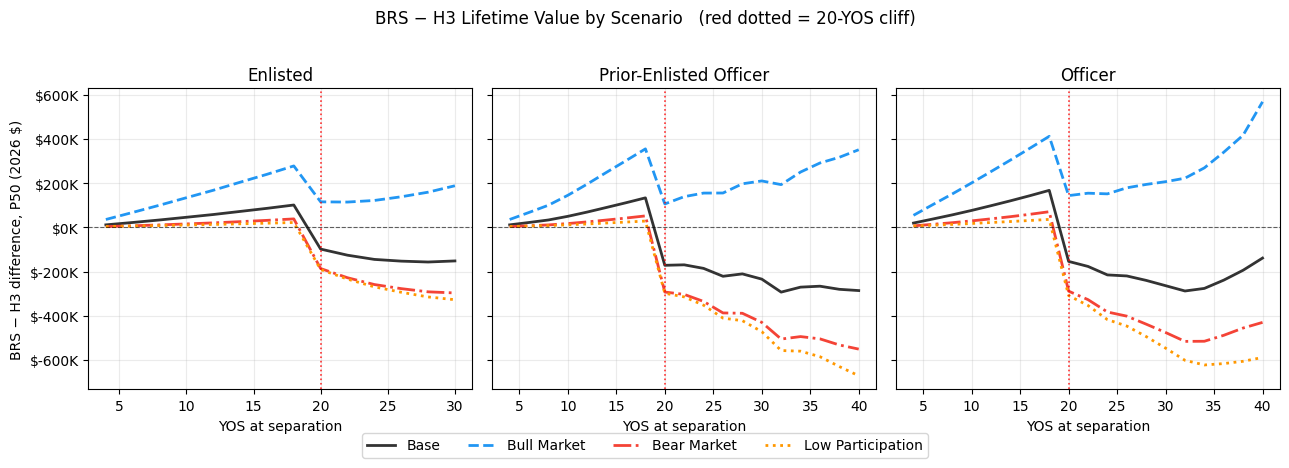

In [8]:
def scen_curve(profile, p):
    """P50 BRS - H3 curve across the profile's YOS grid."""
    ys = VALID_SCENARIOS[profile]
    vals = [float(np.percentile(run_scenario(
        profile, y, pay_df, life_df, p["fs"], p["cs"],
        ENTRY_AGES, n_iter=N_ITER, discount_rate=p["dr"],
        seed=RNG_SEED, member_rate=p["mbr"])["brs_adv"], 50))
        for y in ys]
    return ys, vals


scen_p50 = {s: {prof: scen_curve(prof, p)
                for prof in VALID_SCENARIOS}
            for s, p in scenarios.items()}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharey=True)
for ax, (prof, title) in zip(axes, PROFILE_TITLES.items()):
    for s, (color, ls) in SCEN_STYLE.items():
        ys, vals = scen_p50[s][prof]
        ax.plot(ys, vals, label=s, color=color, ls=ls, lw=2)
    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
    ax.axvline(20, color="red", lw=1.2, ls=":", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("YOS at separation")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
    ax.grid(alpha=0.25)
axes[0].set_ylabel("BRS − H3 difference, P50 (2026 $)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle("BRS − H3 Lifetime Value by Scenario   "
             "(red dotted = 20-YOS cliff)", y=1.02)
plt.tight_layout()
plt.show()

### Where the sign flips

- **Before vesting (≲18 YOS): BRS leads in every regime.**
  The government TSP contribution is the only deferred pay, so
  the difference is positive — Officer 10-YOS spans +\$18K
  (Low Participation) to +\$202K (Bull).
- **At the 20-YOS cliff: regime-dependent.** Base is negative
  for all three (Officer −\$154K, Enlisted −\$98K, PEO
  −\$172K); only **Bull Market** flips every profile positive
  (Officer +\$144K). Bear deepens it to −\$289K (Officer).
- **Long careers (30 YOS): H3's lead grows** under Base
  (Officer −\$264K), worst under Low Participation (−\$546K);
  Bull still flips positive (+\$207K).

**Takeaway.** The crossover is governed mainly by realized
returns and participation. A sustained bull market with low
inflation is the one regime that makes BRS win at and beyond
the cliff.

In [9]:
pts = [10, 20, 30]
records = []
for s in scenarios:
    for prof in VALID_SCENARIOS:
        ys, vals = scen_p50[s][prof]
        m = dict(zip(ys, vals))
        for y in pts:
            if y in m:
                records.append({"Scenario": s,
                                "Profile": PROFILE_TITLES[prof],
                                "YOS": y, "P50": m[y]})

summary = (pd.DataFrame(records)
           .pivot_table(index="Scenario",
                        columns=["Profile", "YOS"],
                        values="P50", aggfunc="first")
           .reindex(["Enlisted", "Prior-Enlisted Officer",
                     "Officer"], axis=1, level=0)
           .reindex(list(scenarios), axis=0))

# Values in $K, constant 2026 dollars.
(summary / 1_000).round(1)

Profile           Enlisted               Prior-Enlisted Officer                \
YOS                     10     20     30                     10     20     30   
Scenario                                                                        
Base                  45.9  -98.2 -151.8                   50.2 -171.6 -234.1   
Bull Market          134.4  115.7  188.5                  145.4  106.1  210.3   
Bear Market           15.8 -186.3 -296.7                   17.4 -292.6 -429.8   
Low Participation     10.8 -190.8 -327.3                   11.6 -298.0 -471.8   

Profile           Officer                
YOS                    10     20     30  
Scenario                                 
Base                 76.9 -153.9 -263.8  
Bull Market         201.5  143.9  206.9  
Bear Market          29.6 -288.6 -475.7  
Low Participation    17.7 -308.6 -546.5

## 3. Separation-Timing Sensitivity

The fiscal model (nb04) weights each YOS by its DoD
separation probability — estimated on a force recruited and
retained largely under High-Three. As BRS cohorts come to
dominate, that curve will likely drift. **How robust is the
per-entrant DoD-savings result to the assumed separation
timing?**

This is a *mechanical what-if*, not a behavioral prediction:
we reshape the weights by hand and recompute the expectation.
Per-scenario costs and the Monte Carlo are unchanged; only
the weights move. Scope is per-entrant (H3_GovtCost,
BRS_GovtCost, DoD_Savings) — no force totals.

**Hypothesis** (assumed magnitudes): shift mass toward
earlier / mid-career separation, slightly fewer reaching 20.

| Phase | YOS | Δ mass |
|---|---|---|
| First term | ≤ 6 | −4 pts |
| Early mid | 7–12 | +4 pts |
| Late mid | 13–19 | +2 pts |
| Career | 20+ | −2 pts |

Deltas sum to zero; each is spread across the phase's YOS in
proportion to baseline weight. Expected cost is linear in the
weights, so savings move monotonically from baseline to full
shift — we report the two endpoints.

In [10]:
fiscal = pd.read_csv(f"{BASE}/fiscal_results.csv")
weights = pd.read_csv(f"{BASE}/scenario_weights.csv")
sep_w = {p: s.set_index("SepYOS")["Weight"]
         for p, s in weights.groupby("Profile")}


def expected(w, profile, col):
    """Separation-weighted per-entrant expectation."""
    s = (fiscal[fiscal["Profile"] == profile]
         .set_index("SepYOS"))
    return float((w * s.reindex(w.index)[col]).sum())


print("Baseline per-entrant DoD savings (reproduces nb04):")
for prof in VALID_SCENARIOS:
    ds = expected(sep_w[prof], prof, "DoD_Savings")
    print(f"  {PROFILE_TITLES[prof]:22} ${ds/1e3:5.1f}K")

Baseline per-entrant DoD savings (reproduces nb04):
  Enlisted               $ 24.1K
  Prior-Enlisted Officer $100.2K
  Officer                $ 95.3K


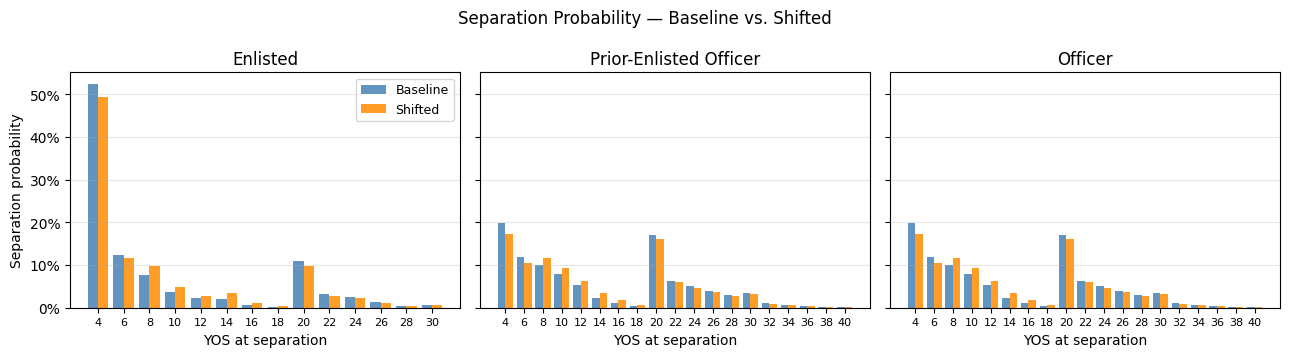

In [11]:
BANDS = {
    "First term (≤6)":  lambda y: y <= 6,
    "Early mid (7–12)": lambda y: 7 <= y <= 12,
    "Late mid (13–19)": lambda y: 13 <= y <= 19,
    "Career (20+)":     lambda y: y >= 20,
}
BAND_DELTAS = {"First term (≤6)": -0.04, "Early mid (7–12)": 0.04,
               "Late mid (13–19)": 0.02, "Career (20+)": -0.02}


def shift_weights(w):
    """Apply BAND_DELTAS, spread within each band by baseline
    share. Stays a probability distribution (sums to 1, >= 0)."""
    out = w.copy()
    for band, delta in BAND_DELTAS.items():
        members = [y for y in w.index if BANDS[band](y)]
        mass = float(w[members].sum())
        for y in members:
            out[y] += delta * w[y] / mass
    assert abs(out.sum() - 1.0) < 1e-9 and (out >= -1e-12).all()
    return out


sep_w_shift = {p: shift_weights(sep_w[p])
               for p in VALID_SCENARIOS}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
bw = 0.4
for ax, prof in zip(axes, VALID_SCENARIOS):
    w0, w1 = sep_w[prof], sep_w_shift[prof]
    x = np.arange(len(w0))
    ax.bar(x - bw / 2, w0.values, bw, label="Baseline",
           color="steelblue", alpha=0.85)
    ax.bar(x + bw / 2, w1.values, bw, label="Shifted",
           color="darkorange", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(w0.index.astype(str), fontsize=8)
    ax.set_xlabel("YOS at separation")
    ax.set_title(PROFILE_TITLES[prof])
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Separation probability")
axes[0].legend(fontsize=9)
fig.suptitle("Separation Probability — Baseline vs. Shifted")
plt.tight_layout()
plt.show()

In [12]:
print("Per-entrant DoD savings: baseline -> shifted")
for prof in VALID_SCENARIOS:
    b = expected(sep_w[prof], prof, "DoD_Savings")
    f = expected(sep_w_shift[prof], prof, "DoD_Savings")
    print(f"  {PROFILE_TITLES[prof]:22}"
          f" ${b/1e3:5.1f}K -> ${f/1e3:5.1f}K"
          f"  (Δ ${(f - b)/1e3:+.1f}K, {(f - b)/b:+.0%})")

print("\nOfficer Δ decomposed by phase (linear in weights):")
w0 = sep_w["Officer"]
sav = (fiscal[fiscal["Profile"] == "Officer"]
       .set_index("SepYOS")["DoD_Savings"])
total = 0.0
for band, delta in BAND_DELTAS.items():
    members = [y for y in w0.index if BANDS[band](y)]
    mass = float(w0[members].sum())
    c = sum(delta * w0[y] / mass * sav[y] for y in members)
    total += c
    print(f"  {band:16} {delta:+.2f}: ${c/1e3:+5.1f}K")
print(f"  {'Total':16}        ${total/1e3:+5.1f}K")

Per-entrant DoD savings: baseline -> shifted
  Enlisted               $ 24.1K -> $ 19.4K  (Δ $-4.6K, -19%)
  Prior-Enlisted Officer $100.2K -> $ 93.2K  (Δ $-7.0K, -7%)
  Officer                $ 95.3K -> $ 87.4K  (Δ $-8.0K, -8%)

Officer Δ decomposed by phase (linear in weights):
  First term (≤6)  -0.04: $ +0.5K
  Early mid (7–12) +0.04: $ -1.5K
  Late mid (13–19) +0.02: $ -1.5K
  Career (20+)     -0.02: $ -5.4K
  Total                   $ -8.0K


### Reading the shift

Baseline reproduces nb04 exactly (Officer \$95.3K, Enlisted
\$24.1K, PEO \$100.2K). Under the full shift:

| Profile | Baseline | Shifted | Δ |
|---|---|---|---|
| Enlisted | \$24.1K | \$19.4K | −19% |
| Prior-Enlisted Officer | \$100.2K | \$93.2K | −7% |
| Officer | \$95.3K | \$87.4K | −8% |

Savings erode but **never flip sign**. Of the Officer −\$8.0K,
nearly all (−\$5.4K) is the 2-pt move off the 20-YOS phase,
where BRS is much cheaper for DoD; the mid-career additions
cost −\$1.5K each. Enlisted is most sensitive in percent terms
— a small baseline saving against a large first-term mass.

**Takeaway.** The nb04 conclusion — BRS ≈ 10% cheaper per
entrant — holds under a plausible earlier-separation shift. A
behavioral move would narrow, not erase, the savings. This
bounds the result; it does not predict behavior.

## Conclusion

Across all three stress tests the headline findings from
nb03–04 hold:

1. **At the 20-YOS cliff, High-Three leads** under the
   empirical baseline for every profile and under every
   single-parameter stress. Only a sustained bull market with
   low inflation flips BRS ahead.
2. **The member result is driven by realized TSP returns,
   inflation, and participation** — the three largest tornado
   bars — not by discounting or longevity.
3. **The fiscal result is robust to separation timing:** BRS
   stays ≈10% cheaper per entrant under a plausible
   earlier-separation reweighting.

The comparison stays deliberately neutral: BRS trades a
smaller guaranteed pension for a portable, earlier-vesting
TSP benefit. Which yields more depends on career length,
markets, and behavior — exactly the dimensions stressed
here.